# Experiment 8. Build an encoder and a decoder architecture for a VAE using a deep learning framework.


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 236kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.39MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.2MB/s]


Epoch 1/10 | Loss: 283.1418
Epoch 2/10 | Loss: 256.4887
Epoch 3/10 | Loss: 250.3141
Epoch 4/10 | Loss: 247.3747
Epoch 5/10 | Loss: 245.7257
Epoch 6/10 | Loss: 244.7043
Epoch 7/10 | Loss: 244.0548
Epoch 8/10 | Loss: 243.4973
Epoch 9/10 | Loss: 243.0614
Epoch 10/10 | Loss: 242.7709


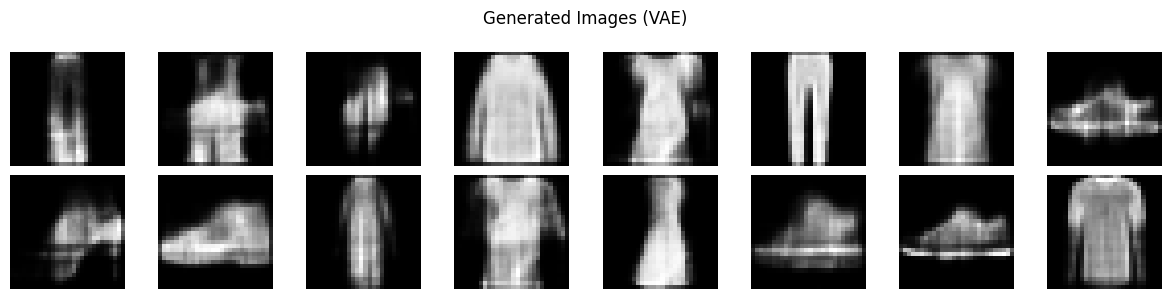

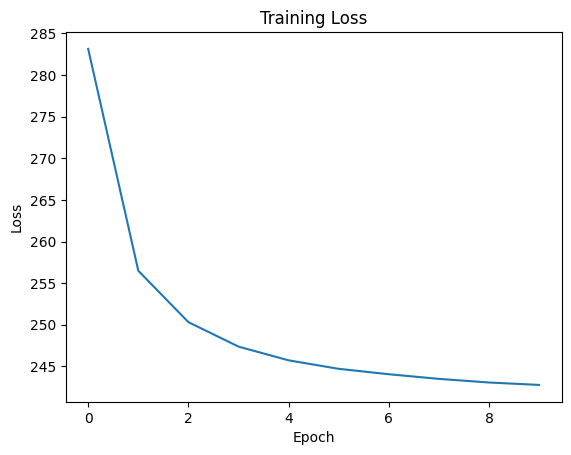

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Step 1: Load Data
transform = transforms.ToTensor()

dataset = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Step 2: Hyperparameters
latent_dim = 32
epochs = 10

# Step 3: Encoder
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def forward(self, x):
        x = x.view(-1, 784)
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

#  Step 4: Decoder
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, 256)
        self.fc2 = nn.Linear(256, 784)

    def forward(self, z):
        h = torch.relu(self.fc1(z))
        return torch.sigmoid(self.fc2(h))

encoder = Encoder()
decoder = Decoder()

optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.001)

# Step 5: Reparameterization
def sample_z(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

#  Step 6: Training
losses = []

for epoch in range(epochs):
    total_loss = 0

    for x, _ in loader:
        mu, logvar = encoder(x)
        z = sample_z(mu, logvar)

        x_recon = decoder(z)

        # Loss
        recon_loss = F.binary_cross_entropy(x_recon, x.view(-1, 784), reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu**2 - torch.exp(logvar))
        loss = (recon_loss + kl_loss) / x.size(0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

# Step 7: Generate Images
with torch.no_grad():
    z = torch.randn(16, latent_dim)
    samples = decoder(z).view(16, 1, 28, 28)

# Plot generated images
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(16):
    axes[i//8, i%8].imshow(samples[i].squeeze(), cmap='gray')
    axes[i//8, i%8].axis('off')

plt.suptitle("Generated Images (VAE)")
plt.tight_layout()
plt.show()

#  Step 8: Plot Loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()